# HW2: Linear Kalman Filter for Smartphone Sensors
**Author:** Anastassiya Ryabkova  
**Course:** Advanced Robotics  
**Date:** March 2026

This notebook implements a **1D Linear Kalman Filter** that fuses GPS position measurements with accelerometer data to estimate smartphone trajectory. The experiment was conducted by walking in a straight line with the phone held steady so that the X-axis of the accelerometer aligned with the direction of motion.

## Step 1: Load Data
Load accelerometer and GPS (Location) data from CSV files collected with a smartphone sensor logger app. The accelerometer provides linear acceleration along X, Y, Z axes at ~50 Hz; the GPS provides position (latitude, longitude, altitude) at ~1 Hz.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

acc = pd.read_csv("Accelerometer.csv")
loc = pd.read_csv("Location.csv")

acc.columns = ["t_acc", "ax", "ay", "az"]  # Time (s), X,Y,Z (m/s^2)
loc.columns = ["t_gps", "lat", "lon", "h", "vel", "dir", "h_acc", "v_acc"]

acc.head(), loc.head()


(      t_acc        ax        ay        az
 0  0.000523 -0.035925  1.568887  9.697584
 1  0.020634 -0.054636  1.746718  9.841884
 2  0.040745  0.022603  1.759292  9.487720
 3  0.060856  0.015119  1.827550  9.136251
 4  0.080966  0.158071  1.959575  9.181307,
       t_gps        lat        lon           h  vel  dir      h_acc      v_acc
 0  0.004124  55.751486  48.752774  211.124642  NaN  NaN  10.895014  30.042056
 1  0.005176  55.751489  48.752769  209.980045  NaN  NaN   9.531070  30.000000
 2  0.020904  55.751489  48.752769  209.979020  NaN  NaN   9.531053  30.000036
 3  0.022429  55.751489  48.752769  209.979020  NaN  NaN   9.531053  30.000043
 4  6.009614  55.751490  48.752766  209.980045  NaN  NaN   8.607465  30.000000)

## Step 2: Compute GPS Distance (Measurement z)
Convert GPS (lat, lon) coordinates to 2D Euclidean distance in metres from the starting point using the equirectangular approximation. This scalar distance `pos_gps` serves as the **measurement** z in the Kalman filter.

In [ ]:
R = 6371000.0

lat0 = np.deg2rad(loc["lat"].iloc[0])
lon0 = np.deg2rad(loc["lon"].iloc[0])
lat = np.deg2rad(loc["lat"].values)
lon = np.deg2rad(loc["lon"].values)

dlat = lat - lat0
dlon = lon - lon0

x_gps = R * dlon * np.cos(lat0)
y_gps = R * dlat

pos_gps = np.sqrt(x_gps**2 + y_gps**2)
loc["pos_gps"] = pos_gps

print("Total GPS distance (m):", loc["pos_gps"].iloc[-1])


Total GPS distance (m): 98.79843406408075


## Step 3: Estimate Noise Parameters
Estimate **std_acc** (process noise std) from the first N=500 accelerometer samples — this corresponds to the phone lying still before the walk, so the std reflects sensor noise rather than real motion. Estimate **std_meas** (measurement noise std) from the first N=5 GPS distance points (nearly stationary). These values are used to build the Q and R covariance matrices.

In [ ]:
# выбери N так, чтобы это точно был покой (по времени видно)
N_acc = 500
N_gps = 5   # у GPS мало точек, можно 5–10 первых

std_acc = acc["ax"].iloc[:N_acc].std()
std_meas = loc["pos_gps"].iloc[:N_gps].std()

std_acc, std_meas


(0.134422172861803, 0.2730326544837679)

## Step 4: Interpolate GPS onto Accelerometer Timeline
The accelerometer samples at ~50 Hz and GPS at ~1 Hz. To synchronise the two signals, GPS distance is linearly interpolated onto the accelerometer timestamps using `np.interp`. The mean time step `dt` of the accelerometer is also computed here for use in the state-transition matrix.

In [ ]:
t = acc["t_acc"].values
ax = acc["ax"].values

# Интерполяция GPS-позиции на моменты акселерометра
pos_gps_interp = np.interp(t, loc["t_gps"].values, loc["pos_gps"].values)

dt = np.mean(np.diff(t))
print("dt ~", dt)


dt ~ 0.020110615853659516


## Step 5: Prepare Control Input (u) and Measurement (z)
Set `u` = accelerometer X-axis values (control input: linear acceleration projected along the direction of motion) and `z` = interpolated GPS distance (measurement). The phone was held so that the X-axis aligned with the walking direction.

In [ ]:
u = ax.copy()
z = pos_gps_interp.copy()


## Step 6: Linear Kalman Filter
Implement the discrete-time Linear Kalman Filter with state vector **x = [position, velocity]^T** and control input **u = ax** (acceleration). System matrices:
- **A** (state transition): constant-velocity kinematics
- **B** (control): position and velocity increments from acceleration
- **H** (observation): extract position from state
- **Q** (process noise covariance): scaled by std_acc^2
- **R** (measurement noise covariance): scaled by max(std_meas, 3.0)^2

For each timestep: **Predict** state and covariance using accelerometer, then **Update** using GPS measurement.

In [ ]:
A = np.array([[1, dt],
              [0, 1]])

B = np.array([[0.5*dt**2],
              [dt]])

H = np.array([[1, 0]])

Q = np.array([[std_acc**2, 0],
              [0, std_acc**2]])
R = np.array([[max(std_meas, 3.0)**2]])  # если std_meas почти 0, берём ~3 м

x_est = np.array([[0.0],
                  [0.0]])
P = np.eye(2) * 1.0

pos_kf = []
vel_kf = []

for k in range(len(t)):
    u_k = u[k]
    z_k = z[k]

    # Prediction
    x_pred = A @ x_est + B * u_k
    P_pred = A @ P @ A.T + Q

    # Update
    y_k = np.array([[z_k]]) - H @ x_pred
    S_k = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S_k)

    x_est = x_pred + K @ y_k
    P = (np.eye(2) - K @ H) @ P_pred

    pos_kf.append(x_est[0, 0])
    vel_kf.append(x_est[1, 0])

pos_kf = np.array(pos_kf)
vel_kf = np.array(vel_kf)


## Step 7: Visualisation and Results
Plot **GPS distance** vs **Kalman-filtered distance** over time. The Kalman filter smooths the step-like GPS signal by continuously integrating accelerometer data between GPS updates. The final total distance from both methods should be close, confirming that the filter converged correctly.

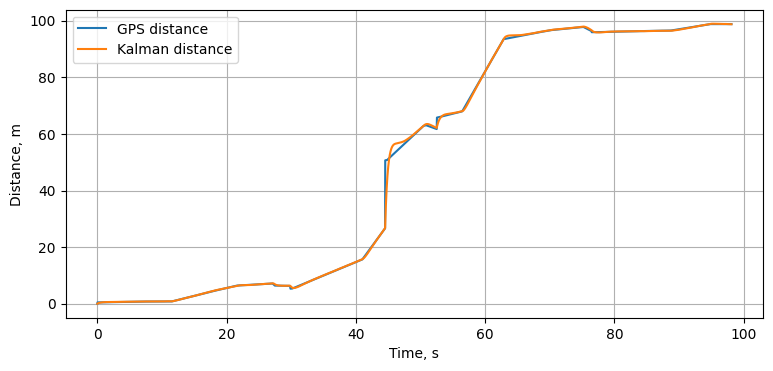

Total GPS distance (interp): 98.79843406408075 m
Total KF distance: 98.76030726571462 m


In [ ]:
plt.figure(figsize=(9,4))
plt.plot(t, z, label="GPS distance")
plt.plot(t, pos_kf, label="Kalman distance")
plt.xlabel("Time, s")
plt.ylabel("Distance, m")
plt.legend()
plt.grid(True)
plt.show()

print("Total GPS distance (interp):", z[-1], "m")
print("Total KF distance:", pos_kf[-1], "m")
